# Error Normalized Distance Study
In this notebook we study the error normalized distance distribution, and its correlation with other parameters, computed from our own crossmatch algorithm using only those stars present in the Marrese crossmatch

We make use of the Gaia DR3 and Hipparcos catalogues
Further inclusions:
 -  Proper Motion Anomaly table by Kervella+21

In [1]:
# Library Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import copy

# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from plotting_functions import set_styles
from data_queries import query_extra_data
from astrometry_equations import rayleigh
set_styles()

# Data
We have to extract our Gaia astrometry from locally stored catalogues, because it is backpropagated to J1991.25. However, all other parameters we just query from the Archive for flexibility, and due to storage limitations

In [2]:
# Potential Parameters throughout this notebook
gaia_cat_ext = '+EIB'
xm_radius = '1as'
xm_selection = 'nearest'

In [3]:
# Hipparcos - Gaia indexes of the cross match
crossmatch_idxs = np.load(f'../../results/marrese_crossmatch{gaia_cat_ext}_{xm_radius}_best_neighbour_{xm_selection}.npy')
gaia_cat = fits.open(f'../../../data/GaiaBaseCat{gaia_cat_ext}.fits')[1].data

# Make a table matching the XM order containing all propagated Gaia astrometry
pos_gaia_table_full = copy.deepcopy(gaia_cat)
pos_gaia_table_full = pos_gaia_table_full[crossmatch_idxs[:,2]]
_, pos_hipp_table_full = query_extra_data(crossmatch_idxs, ['ra', 'dec', 'e_ra_rad', 'e_de_rad'], cat='hipp')

print(f'Imported {crossmatch_idxs.shape[0]} potential Gaia - Hipparcos matches')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
Imported 99373 potential Gaia - Hipparcos matches


In [4]:
# Auxiliary data importing from the archive
extra_gaia_data_params = ['phot_g_mean_mag', 'bp_rp', 'ruwe', 'l', 'b']
extra_hipp_data_params = ['hp_mag', 'b_v']

_, extra_gdata = query_extra_data(crossmatch_idxs, extra_gaia_data_params)
_, extra_hdata = query_extra_data(crossmatch_idxs, extra_hipp_data_params, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


In [5]:
# Importing of additional databases

# Analysis

## Error Normalized Distance

In [121]:
# CODE FROM A.G.A. Brown
def error_ellipses(mu, covmat, sigma_levels, **kwargs):
    """
    Given a covariance matrix for a 2D Normal distribution calculate the uncertainty-ellipses and return
    matplotlib patches for plotting them.
    Parameters
    ----------
    mu : float array
        Mean of Normal distribution (2-vector)
    covmat : float array
        Covariance matrix stored as [sigma_x^2, sigma_y^2, sigma_xy]
    sigma_levels : float or 1-D array
        Equivalent n-sigma levels to draw
    Returns
    -------
    patches : list of matplotlib.patches.Ellipse
        List of matplotlib.patches.Ellipse objects
    Other parameters
    ----------------
    **kwargs :
        Extra arguments for matplotlib.patches.Ellipse
    """
    import matplotlib as mpl
    from scipy.special import erf

    sigmaLevels2D = -2.0 * np.log(
        1.0 - erf(np.array([sigma_levels]).flatten() / np.sqrt(2.0))
    )

    eigvalmax = 0.5 * (
        covmat[0]
        + covmat[1]
        + np.sqrt((covmat[0] - covmat[1]) ** 2 + 4 * covmat[2] ** 2)
    )
    eigvalmin = 0.5 * (
        covmat[0]
        + covmat[1]
        - np.sqrt((covmat[0] - covmat[1]) ** 2 + 4 * covmat[2] ** 2)
    )
    angle = np.arctan2((covmat[0] - eigvalmax), -covmat[2]) / np.pi * 180
    errEllipses = []
    for csqr in sigmaLevels2D:
        errEllipses.append(
            mpl.patches.Ellipse(
                mu,
                2 * np.sqrt(csqr * eigvalmax),
                2 * np.sqrt(csqr * eigvalmin),
                angle=angle,
                **kwargs
            )
        )

    return errEllipses

# MOVE THIS TO ASTROMETRY EQUATIONS
def compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full', coordinates='spherical', unit='mas'):
    """Calculates the 2-dimensional error normalized distance, D, between two objects with uncertainties,
    following a variety of possible methods as listed below.

        None:        No error normalization performed, this function just returns the distance between x,y
        Simple:      Uncertainties are approximated as a circle with radius sigma^2 = 0.5(sigma_x^2 + sigma_y^2)
        Directional: Computes D separately in the x and y directions first, and then combines using Pythagoras
        Full:        Utilizes the full covariance matrix and distance vector

    Inputs:
        pos1: Nx2 array containing the [x,y] coordinates of the first object
        pos2: See above, but for the second object
        unc1: Nx3 array containing all (co)variance terms of object 1 necessary for the chosen methods.
              List as [sigma_x^2, sigma_y^2, sigma_xy], not given values are treated as 0. # Maybe this should be np.nan?
        unc2: See above, but for the second object
        method: Choose from none, simple, directional, full. For descriptions see above
        coordinates: If set to spherical, transforms x |-> x cos(y) for distance calculation to account for spherical effects near poles
        unit: Check to ensure trigonometry is performed properly in the case of spherical coordinates

    Outputs:
        error_norm_distances: array of size N describing the error normalized distance for all provided object pairs
    """

    # Bad inputs check
    if not method in ['none', 'simple', 'directional', 'full']:
        raise ValueError(f'method {method} not implemented in this function')
    if not ((pos1.shape == pos2.shape) and (unc1.shape == unc2.shape)):
        raise ValueError(f'position or uncertainty arrays are of different shapes')

    if len(pos1.shape) == 1: # Then N=1
        x1, y1 = pos1
        sigma_x1, sigma_y1, sigma_xy1 = unc1
        x2, y2 = pos2
        sigma_x2, sigma_y2, sigma_xy2 = unc2
    elif len(pos1.shape) == 2:
        # Extract all columns, and store in separate variables
        x1, y1 = pos1[:,0], pos1[:,1]
        sigma_x1, sigma_y1, sigma_xy1 = unc1[:,0], unc1[:,1], unc1[:,2]
        x2, y2 = pos2[:,0], pos2[:,1]
        sigma_x2, sigma_y2, sigma_xy2 = unc2[:,0], unc2[:,1], unc2[:,2]
    else:
        raise ValueError(f'Array with dimension {len(pos1.shape)} not supported')

    # Transform x to x cos(y) to account for spherical effects
    if coordinates == 'spherical':
        if unit == 'rad':
            y1_rad, y2_rad = y1, y2
        elif unit == 'deg':
            y1_rad, y2_rad = np.radians(y1), np.radians(y2)
        elif unit == 'mas':
            y1_rad, y2_rad = np.radians(y1/3.6e6), np.radians(y2/3.6e6) # 3600 * 1e3 = 3.6e6
        else:
            raise NotImplementedError(f'unit {unit} not recognized')
        x1_corr = x1 * np.cos(y1_rad)
        x2_corr = x2 * np.cos(y2_rad)
    else:
        x1_corr = x1
        x2_corr = x2

    # Only method that computes D not from the combined distance
    if method == 'directional':
        total_x_unc = np.sqrt(sigma_x1 + sigma_x2)
        total_y_unc = np.sqrt(sigma_y1 + sigma_y2)

        x_dist_norm = (x1_corr - x2_corr)/total_x_unc
        y_dist_norm = (y1 - y2)/total_y_unc

        return np.sqrt(x_dist_norm**2. + y_dist_norm**2.)

    elif method == 'full':
        # chi^2 = v^T S^-1 v
        # Setup distance vector and covariance matrix
        if len(pos1.shape) > 1:
            delta_distance = np.stack(((x1_corr-x2_corr), (y1-y2)), axis=1)

            cov_mat_top = np.stack((sigma_x1 + sigma_x2, sigma_xy1 * np.sqrt(sigma_x1*sigma_y1) + sigma_xy2 * np.sqrt(sigma_x2*sigma_y2)), axis=1)
            cov_mat_bot = np.stack((sigma_xy1 * np.sqrt(sigma_x1*sigma_y1) + sigma_xy2 * np.sqrt(sigma_x2*sigma_y2), sigma_y1 + sigma_y2), axis=1)

            cov_matrix = np.stack((cov_mat_top, cov_mat_bot), axis=1)
        else:
            delta_distance = np.array([x1_corr - x2_corr, y1 - y2])
            #print(f'v:{delta_distance}')
            cov_matrix = np.array([[sigma_x1+sigma_x2, sigma_xy1*np.sqrt(sigma_x1*sigma_y1)+sigma_xy2*np.sqrt(sigma_x2*sigma_y2)], [sigma_xy1*np.sqrt(sigma_x1*sigma_y1)+sigma_xy2*np.sqrt(sigma_x2*sigma_y2), sigma_y1+sigma_y2]])
            #print(f'S: {cov_matrix}')
            #cov_matrix = np.array([[sigma_x1+sigma_x2, sigma_xy1+sigma_xy2], [sigma_xy1+sigma_xy2, sigma_y1+sigma_y2]])
        cov_matrix_inverse = np.linalg.inv(cov_matrix) # Inverts each of the N matrices individually
        #print(f'S^-1: {cov_matrix_inverse}')

        # Calculate chi squared
        if len(pos1.shape) > 1:
            # https://stackoverflow.com/questions/35894631/multiply-array-of-vectors-with-array-of-matrices-return-array-of-vectors
            # Figure out how einsum exactly works (and better name?)
            vt_Sinverse = np.einsum('ij,ijk->ik', delta_distance, cov_matrix_inverse)
            chi_squared = np.einsum('ij,ij->i', vt_Sinverse, delta_distance)
        else:
            vt_Sinverse = np.matmul(delta_distance, cov_matrix_inverse)
            chi_squared = np.matmul(vt_Sinverse, delta_distance)
            #print(f'chi_squared {chi_squared}')

        return np.sqrt(np.abs(chi_squared))

    # Start by computing distances
    distances = np.sqrt((x1_corr - x2_corr)**2. + (y1 - y2)**2.)

    if method == 'none':
        return distances
    elif method == 'simple':
        avg_unc1_sq = 0.5*(sigma_x1 + sigma_y1)
        avg_unc2_sq = 0.5*(sigma_x2 + sigma_y2)
        combined_unc = np.sqrt(avg_unc1_sq + avg_unc2_sq)

        return distances/combined_unc

In [133]:
brandt_factor = 1.36
# Compute the complete error normalized distances array
pos_hipp = np.array([pos_hipp_table_full[:,0], pos_hipp_table_full[:,1]]).T*3.6e6
pos_gaia = np.array([pos_gaia_table_full['ra_prop'], pos_gaia_table_full['dec_prop']]).T*3.6e6
unc_hipp = np.array([pos_hipp_table_full[:,2]**2, pos_hipp_table_full[:,3]**2, np.zeros_like(pos_hipp_table_full[:,3])]).T
unc_gaia = np.array([brandt_factor * pos_gaia_table_full['e_ra_prop']**2, brandt_factor * pos_gaia_table_full['e_de_prop']**2, pos_gaia_table_full['ra_dec_prop']]).T

print(pos_hipp[0], pos_gaia[0], unc_hipp[0], unc_gaia[0])
error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full')
print(pos_hipp[0], pos_gaia[0], unc_hipp[0], unc_gaia[0])

[ 1.36705507e+04 -7.01958146e+07] [ 1.37145531e+04 -7.01958005e+07] [0.9025 0.2809 0.    ] [5.04493211e+02 2.68510222e+02 7.48338696e-02]
[ 1.36705507e+04 -7.01958146e+07] [ 1.37145531e+04 -7.01958005e+07] [0.9025 0.2809 0.    ] [5.04493211e+02 2.68510222e+02 7.48338696e-02]


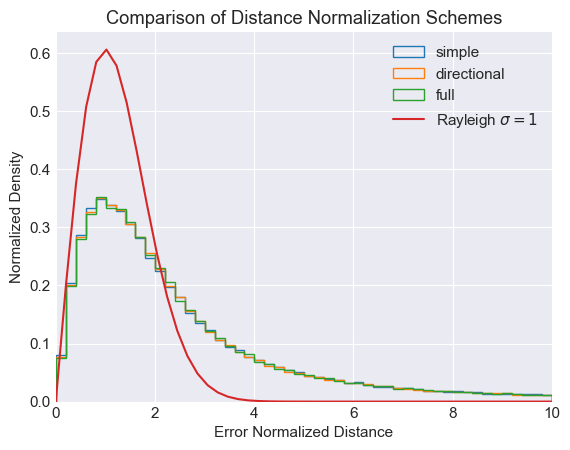

In [134]:
#set_styles()
# Investigate the effect of different normalization methods
for method in ['simple', 'directional', 'full']:#, 'none']:
    error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method=method)
    plt.hist(error_norm_distances[error_norm_distances < 10], bins=50, density=True, label=method, histtype='step')

x = np.linspace(0, 10, 50)
plt.plot(x, rayleigh(x, 1), label=r'Rayleigh $\sigma = 1$')
plt.legend()
plt.xlim(0, 10)
plt.xlabel('Error Normalized Distance')
plt.ylabel('Normalized Density')
plt.title('Comparison of Distance Normalization Schemes')
plt.savefig('temp_brandt')
plt.show()

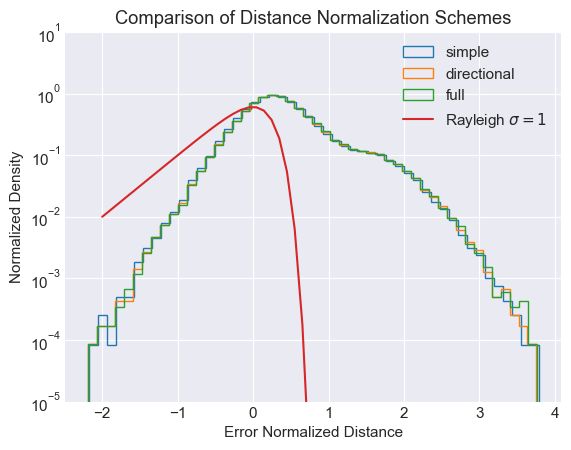

In [135]:
# Investigate the effect of different normalization methods in log space
for method in ['simple', 'directional', 'full']:#, 'none']:
    error_norm_distances = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method=method)
    plt.hist(np.log10(error_norm_distances), log=True, bins=50, density=True, label=method, histtype='step')

x = np.logspace(-2, 3,  50)
plt.plot(np.log10(x), rayleigh(x, 1), label=r'Rayleigh $\sigma = 1$')
plt.legend()

plt.xlabel('Error Normalized Distance')
plt.ylabel('Normalized Density')
plt.title('Comparison of Distance Normalization Schemes')
plt.ylim(1e-5,1e1)
plt.savefig('temp_brandt_log')
plt.show()

-0.009846098670664829
show


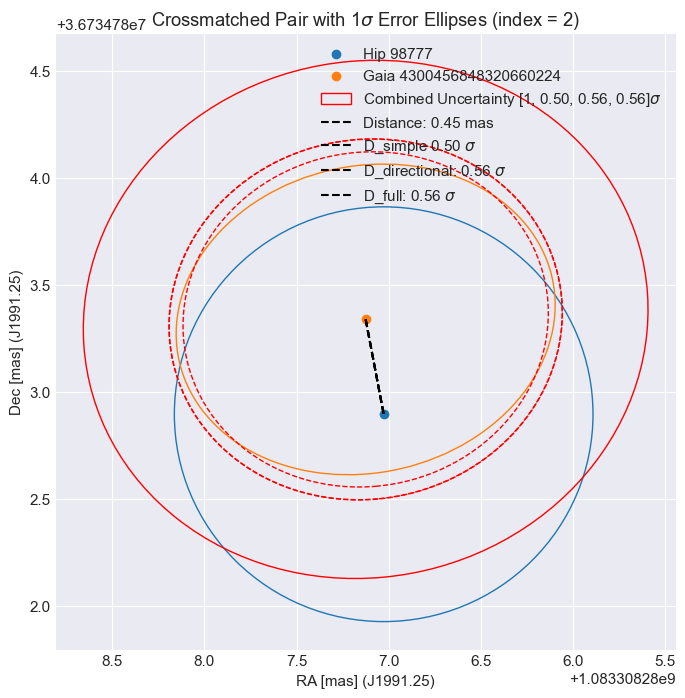

In [120]:
#quick mass plot

# Plot single crossmatch with error ellipses
center_on_gaia = False
coordinates = 'cartesian'
deg_to_mas = 3600*1e3
i = np.random.choice(crossmatch_idxs.shape[0])
###

# RA, Dec are given in degrees. Convert both to mas to conform with the uncertainties
pos_hipp = np.array(pos_hipp_table_full[i][:2])*deg_to_mas
pos_gaia = np.array([pos_gaia_table_full[i]['ra_prop'], pos_gaia_table_full[i]['dec_prop']])*deg_to_mas

if center_on_gaia:
    # Shift potions such that the Gaia object is at (0, 0)
    pos_hipp -= pos_gaia
    pos_gaia -= pos_gaia

if coordinates == 'cartesian':
    # Then we have to make sure the alpha-uncertainties are scaled back to normal
    hipp_dec_rad, gaia_dec_rad = np.radians(pos_hipp[1]/3.6e6), np.radians(pos_gaia[1]/3.6e6) # 3600 * 1e3 = 3.6e6
    hipp_ra_corr, gaia_ra_corr = np.cos(hipp_dec_rad), np.cos(gaia_dec_rad)

unc_hipp = np.array([pos_hipp_table_full[i][2]**2, pos_hipp_table_full[i][3]**2, 0])
unc_gaia = np.array([(pos_gaia_table_full[i]['e_ra_prop']/hipp_ra_corr)**2, (pos_gaia_table_full[i]['e_de_prop']/gaia_ra_corr)**2, pos_gaia_table_full[i]['ra_dec_prop']])

# Distance measure using all four different methods
distance_mas = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='none', coordinates=coordinates)
D_simple = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='simple', coordinates=coordinates)
D_directional = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='directional', coordinates=coordinates)
D_full = compute_error_normalized_distance(pos_hipp, pos_gaia, unc_hipp, unc_gaia, method='full', coordinates=coordinates)

# Draw error ellipses individually using agapylib
ellipse_kwargs = {
    'fc': None,
    'fill': False
}
ellipse_hipp = error_ellipses(pos_hipp, unc_hipp, 1, **ellipse_kwargs, ec='C0')
ellipse_gaia = error_ellipses(pos_gaia, unc_gaia, 1, **ellipse_kwargs, ec='C1')
ellipse_combined = error_ellipses(pos_gaia, unc_gaia+unc_hipp, 1, **ellipse_kwargs, ec='red', label=rf'Combined Uncertainty [1, {D_simple:.2f}, {D_directional:.2f}, {D_full:.2f}]$\sigma$')
ellipse_combined_D = error_ellipses(pos_gaia, unc_gaia+unc_hipp, [D_simple, D_directional, D_full], **ellipse_kwargs, ec='red', ls='--')#$, label=rf'Combined Uncertainty {D_full:.2f}$\sigma$')

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()

ax.scatter(pos_hipp[0], pos_hipp[1], c='C0', label=f'Hip {crossmatch_idxs[i][0]}')
ax.add_patch(ellipse_hipp[0])

ax.scatter(pos_gaia[0], pos_gaia[1], c='C1', label=f'Gaia {crossmatch_idxs[i][1]}')
ax.add_patch(ellipse_gaia[0])

ax.add_patch(ellipse_combined[0])
for i in range(len(ellipse_combined_D)):
    ax.add_patch(ellipse_combined_D[i])


ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=f'Distance: {distance_mas:.2f} mas')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_simple {D_simple:.2f} $\sigma$')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_directional: {D_directional:.2f} $\sigma$')
ax.plot([pos_gaia[0], pos_hipp[0]], [pos_gaia[1], pos_hipp[1]], c='black', ls='--', label=fr'D_full: {D_full:.2f} $\sigma$')

if center_on_gaia:
    ax.set_xlabel(r'$\Delta$ RA [mas]')
    ax.set_ylabel(r'$\Delta$ Dec [mas]')
else:
    ax.set_xlabel('RA [mas] (J1991.25)')
    ax.set_ylabel('Dec [mas] (J1991.25)')
ax.set_title(rf'Crossmatched Pair with 1$\sigma$ Error Ellipses (index = {i})')

ax.invert_xaxis()
plt.legend()
plt.savefig(f'temp{k}.png', bbox_inches='tight')
print('show')
plt.show()


# Comparison with Parameters